# Introduction

This project focuses on Exploratory Data Analysis (EDA) of a Superstore Sales dataset using Python. The objective was to analyze sales performance, customer behavior, product trends, and business growth patterns through data visualization and statistical insights.

Using Pandas, NumPy, Matplotlib, and Seaborn, I cleaned the dataset, handled missing values, performed data transformation, and created visualizations to uncover meaningful business insights. The analysis helps identify top-performing products, valuable customer segments, preferred shipping methods, regional sales performance, and overall sales trends.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\CHAIT\Downloads\train.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Cleaning data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df["Postal Code"].isnull().sum()

np.int64(11)

In [5]:
df=df.fillna(0)

In [6]:
df["Postal Code"].isnull().sum()

np.int64(0)

In [7]:
df["Postal Code"]=df["Postal Code"].astype(int)

In [8]:
df["Postal Code"].dtype

dtype('int64')

In [9]:
df["Order Date"]=pd.to_datetime(df["Order Date"],errors="coerce")

In [10]:
print("Start:",df["Order Date"].min())
print("End:",df["Order Date"].max())

Start: 2015-01-02 00:00:00
End: 2018-12-11 00:00:00


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     3959 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   int64         
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [12]:
df=df.drop(["Product ID","Ship Date"],axis=1)

In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Data Visulization

## Which Product sell the most ?

In [14]:
print(df.head(1))

   Row ID        Order ID Order Date     Ship Mode Customer ID Customer Name  \
0       1  CA-2017-152156 2017-08-11  Second Class    CG-12520   Claire Gute   

    Segment        Country       City     State  Postal Code Region  \
0  Consumer  United States  Henderson  Kentucky        42420  South   

    Category Sub-Category                       Product Name   Sales  
0  Furniture    Bookcases  Bush Somerset Collection Bookcase  261.96  


In [15]:
count=df["Product Name"].value_counts().sort_values(ascending=False).head(1)

In [16]:
print(count)

Product Name
Staple envelope    47
Name: count, dtype: int64


## Which State Generate the higest Sales ?

In [17]:
print(df.head(1))

   Row ID        Order ID Order Date     Ship Mode Customer ID Customer Name  \
0       1  CA-2017-152156 2017-08-11  Second Class    CG-12520   Claire Gute   

    Segment        Country       City     State  Postal Code Region  \
0  Consumer  United States  Henderson  Kentucky        42420  South   

    Category Sub-Category                       Product Name   Sales  
0  Furniture    Bookcases  Bush Somerset Collection Bookcase  261.96  


In [18]:
group_wise_sales=df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
print(group_wise_sales)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


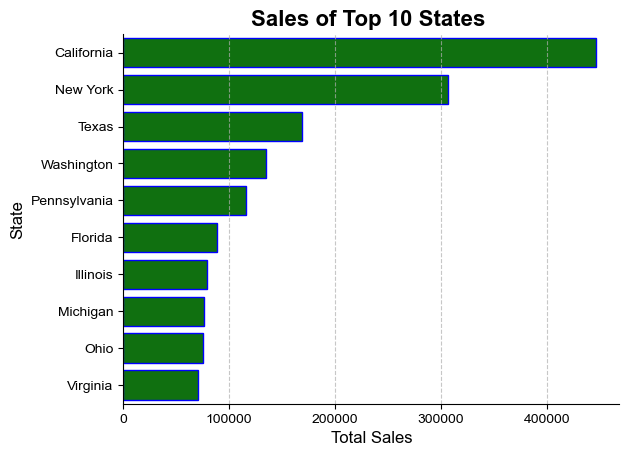

In [19]:
sns.barplot(y=group_wise_sales.index,x=group_wise_sales,edgecolor="blue",color="green")
sns.set_style("dark")
sns.despine()
plt.title("Sales of Top 10 States ",fontsize=16,fontweight="bold")
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.grid(axis='x',alpha=0.7,linestyle="--")

California has highest Sales

## which customer segment is most valueable ?

In [20]:
count=df["Segment"].value_counts()
print(count)

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64


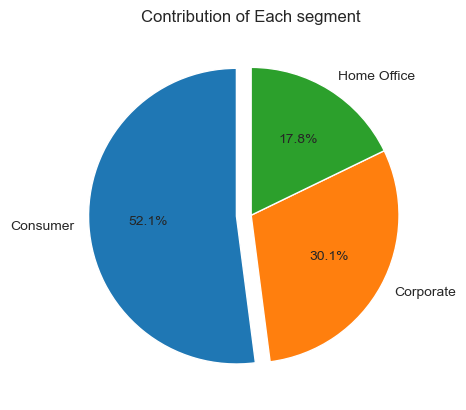

In [21]:
plt.pie(count,labels=count.index,autopct="%1.1f%%",explode=[0.1,0,0],startangle=90)
explode=[0.1,0,0]
plt.title("Contribution of Each segment")
plt.show()


Cousumer Segment is most valueable and has highest contribution

## Customer loyalty

In [22]:
df.head()

,Row ID,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [23]:
group=df.groupby(['Customer ID','Segment','Customer Name'])['Customer ID'].value_counts().sort_values(ascending=False).reset_index(name="Total Orders").head(10)

In [24]:
print(group)

  Customer ID      Segment        Customer Name  Total Orders
0    WB-21850     Consumer        William Brown            35
1    PP-18955  Home Office           Paul Prost            34
2    MA-17560  Home Office         Matt Abelman            34
3    JL-15835     Consumer             John Lee            33
4    CK-12205     Consumer  Chloris Kastensmidt            32
5    SV-20365     Consumer          Seth Vernon            32
6    JD-15895    Corporate     Jonathan Doherty            32
7    AP-10915     Consumer       Arthur Prichep            31
8    ZC-21910     Consumer     Zuschuss Carroll            31
9    EP-13915     Consumer           Emily Phan            31


 The most repeated cutomer belongs to Consumer and Home Office segment and they are more loyal

William Brown is the most frequent customer with 35 orders. The Consumer segment dominates the list of top customers, suggesting that individual consumers are the primary source of repeat purchases and customer loyalty

## which was the most preffered shipment mode ?

In [25]:
shipment=df["Ship Mode"].value_counts().reset_index()

In [26]:
print(shipment)

        Ship Mode  count
0  Standard Class   5859
1    Second Class   1902
2     First Class   1501
3        Same Day    538


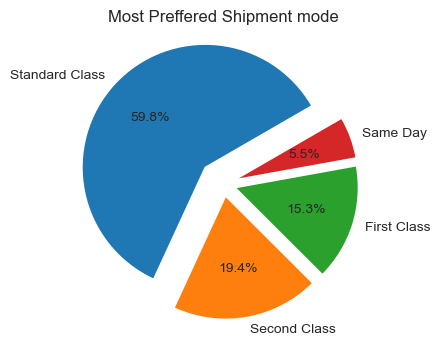

In [27]:
plt.figure(figsize=(10,4))
plt.title("Most Preffered Shipment mode")
plt.pie(shipment['count'],labels=shipment['Ship Mode'],startangle=30,explode=[0.2,0.1,0.1,0.1],autopct='%1.1f%%')
plt.show()

The most prefered shipment mode is Stadard Class

## which state has the most customer

In [28]:
df.head()

region=df['State'].value_counts().reset_index().head(10)
region=region.rename(columns={'count':'Number of customer'})
print(region)

            State  Number of customer
0      California                1946
1        New York                1097
2           Texas                 973
3    Pennsylvania                 582
4      Washington                 504
5        Illinois                 483
6            Ohio                 454
7         Florida                 373
8        Michigan                 253
9  North Carolina                 247


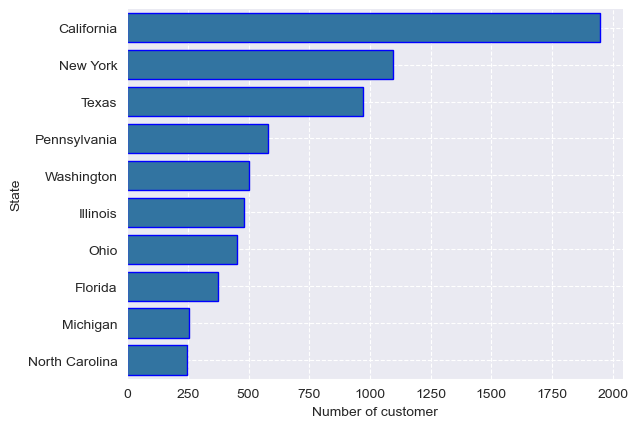

In [29]:
sns.barplot(y=region['State'],x=region['Number of customer'],edgecolor='blue')
sns.set_style('dark')
sns.despine()
plt.grid(linestyle='--')

Most of the customer were from the California State

## Which was the most selling Category ?

In [30]:
df.head(1)
category=df['Category'].value_counts().reset_index()
category=category.rename(columns={'count':'Total Sales'})
print(category)

          Category  Total Sales
0  Office Supplies         5909
1        Furniture         2078
2       Technology         1813


The most saling category was Office Supplies

## Which year had most sale ?

In [31]:
df.head()

,Row ID,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [32]:
sale=df.groupby("Order Date")["Sales"].sum().sort_values(ascending=False).head().reset_index()
sale=sale.rename(columns={"Sales":"Total Sales"})
print(sale)

  Order Date  Total Sales
0 2017-02-10    18452.972
1 2015-08-09    14228.428
2 2016-08-11    12196.997
3 2018-04-11    10668.096
4 2018-02-12     9951.182


# Trend of sales by year

Text(0.5, 1.0, 'Trend of sales ')

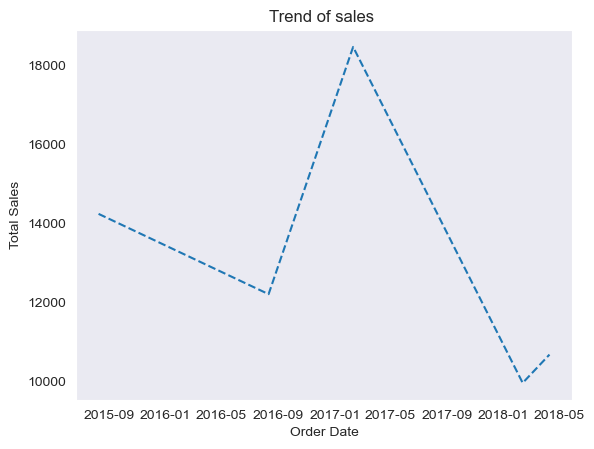

In [33]:
sns.lineplot(x="Order Date",y="Total Sales",data=sale,linestyle="--")
sns.set_style("darkgrid")
sns.set_palette("Set1")
plt.title("Trend of sales ")

There was Growth in sales from 2016 

## Quateryly Sales of 2017

In [34]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)
q_2017=df[df["Order Date"].dt.year==2017]

In [35]:
q_sales=q_2017.resample("Q",on="Order Date")["Sales"].sum().reset_index()

C:\Users\CHAIT\AppData\Local\Temp\ipykernel_1216\1004547479.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_sales=q_2017.resample("Q",on="Order Date")["Sales"].sum().reset_index()


In [36]:

print(q_sales)


  Order Date       Sales
0 2017-03-31  95292.7430
1 2017-06-30  56171.6958
2 2017-09-30  50446.9916
3 2017-12-31  64343.1705


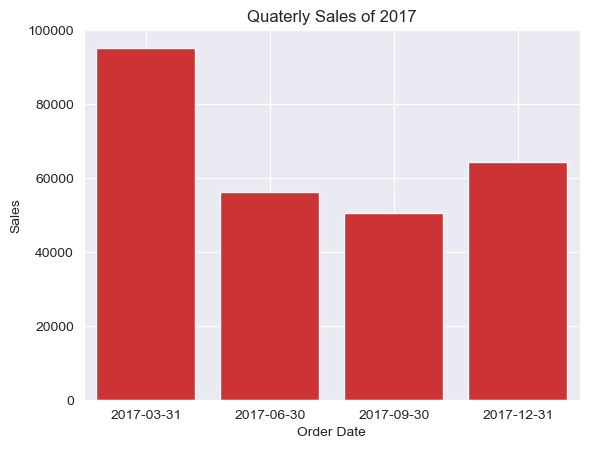

In [37]:
sns.barplot(x=q_sales["Order Date"],y=q_sales["Sales"])
sns.set_style("ticks")
plt.title("Quaterly Sales of 2017")
plt.grid(True)
sns.despine()

There was a sharp increase from Q3 to Q4.

## Conclusion / Key Findings

The analysis revealed several important business insights:

- California generated the highest sales among all states.

- The Consumer segment was the most valuable customer segment and contributed the largest share of sales.

- William Brown was identified as the most frequent customer, indicating strong customer loyalty.

- Standard Class was the most preferred shipping mode.

- Office Supplies emerged as the best-selling product category.

- Sales showed consistent growth over the years, with a noticeable increase after 2016.

- Quarterly analysis of 2017 indicated stable growth during the middle quarters and a significant increase in Q4, suggesting stronger year-end demand.

Overall, the project demonstrates how Exploratory Data Analysis can transform raw sales data into actionable business insights that support better decision-making and strategic planning.